# Homework 2 - Classification

In this exercise you will use scikit-learn, a popular machine learning package in python to train and tune a classifier. A particularly useful feature is that all classifiers (and linear models) are called using the same API, so it is easy to test between different models (see the sklearn-intro notebook for examples). So in this exercise we will a classification technique (logistic regression) that is representative of methods and challenges you will encounter when using any classification method.


## Dataset 1
The dataset you will be using is default of credit card clients Data Set.
There are two data files: "CreditDefault_training.csv" and "CreditDefault_Xtest.csv"
Both files have the following fields, except the label ("default.payment.next.month") which is not available in "CreditDefault_Xtest.csv"

Features:

1 - LIMIT_BAL:  Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit. <br>
2 - SEX: (1 = male; 2 = female) <br>
3- EDUCATION: (six levels: 1,2,3,4,5,6) <br>
4 - MARRIAGE: (1 = married; 2 = single; 3 = others) <br>
5 - AGE <br>

From "PAY_1" to "PAY_6": History of past payment (Repayment status: -1 = pay duly; 0 = payment delay for one month; 1 = payment delay for two months; . . .; 8 = payment delay for eight months; 8 = payment delay for nine months and above.)<br>
6 - PAY_1: the repayment status in September, 2005 <br>
7 - PAY_2: the repayment status in August, 2005 <br>
...<br>
11 - PAY_6: the repayment status in April, 2005 <br>

From "BILL_AMT1" to "BILL_AMT6": Amount of bill statement (NT dollar).<br>
12 - BILL_AMT1 : amount of bill statement in September, 2005<br>
13 - BILL_AMT2 : amount of bill statement in August, 2005<br>
...<br>
17 - BILL_AMT6 : amount of bill statement in April, 2005<br>

From "PAY_AMT1" to "PAY_AMT6": Amount of previous payment (NT dollar).<br>
18 - PAY_AMT1 : amount paid in September, 2005<br>
19 - PAY_AMT2 : amount paid in August, 2005<br>
...<br>
23 - PAY_AMT6 : amount paid in April, 2005<br>

Target:

default.payment.next.month: binary variable, whether default payment (Yes = 1, No = 0)


Training dataset, "CreditDefault_training.csv", contains 3985 rows and 24 columns. This is the training set containing both of the features and the target.
Test dataset, "CreditDefault_Xtest.csv", contains 1000 rows and 23 columns. This is the test set which only contains the features.

Prediction task is to determine whether there's credit default for a person.



In [1]:
import numpy as np
import pandas as pd

In [5]:
from google.colab import files
uploaded = files.upload()

Saving CreditDefault_train_y.csv to CreditDefault_train_y.csv


In [6]:
import io

In [ ]:
# Load your training data set
data = pd.read_csv('CreditDefault_train_X.csv')
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,16690,260000,1,2,1,46,2,2,2,2,...,86472,87157,88526,90355,4000,4300,3000,3700,3400,3600
1,27797,260000,2,1,2,26,0,0,0,0,...,245186,254614,176211,180845,10368,15186,14614,7211,7850,6912
2,10756,50000,2,2,1,42,0,0,0,0,...,13953,13924,14399,14610,1216,1528,499,700,600,541
3,7590,50000,2,1,2,27,2,0,0,0,...,50725,43492,44377,41297,1881,1915,1472,4012,2008,10002
4,13447,170000,1,1,1,36,-1,-1,-1,-1,...,2015,2015,2015,1925,2015,2015,2015,2015,1925,2105


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         21000 non-null  int64
 1   LIMIT_BAL  21000 non-null  int64
 2   SEX        21000 non-null  int64
 3   EDUCATION  21000 non-null  int64
 4   MARRIAGE   21000 non-null  int64
 5   AGE        21000 non-null  int64
 6   PAY_0      21000 non-null  int64
 7   PAY_2      21000 non-null  int64
 8   PAY_3      21000 non-null  int64
 9   PAY_4      21000 non-null  int64
 10  PAY_5      21000 non-null  int64
 11  PAY_6      21000 non-null  int64
 12  BILL_AMT1  21000 non-null  int64
 13  BILL_AMT2  21000 non-null  int64
 14  BILL_AMT3  21000 non-null  int64
 15  BILL_AMT4  21000 non-null  int64
 16  BILL_AMT5  21000 non-null  int64
 17  BILL_AMT6  21000 non-null  int64
 18  PAY_AMT1   21000 non-null  int64
 19  PAY_AMT2   21000 non-null  int64
 20  PAY_AMT3   21000 non-null  int64
 21  PAY_AMT4   2

## Standardization and One-hot Encoding

Standardize the continuous features and convert categorical variables into dummy variables.<br>
Note the situation where not all repayment status categories necessarily appear in the training dataset for variables 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', but you still need to encode them.<br>
See the values of each column, and do standardization if numerical value or one hot encoding if categorical value.

Standardization and one-hot encoding for training set

**Q1 How many columns do you have after transformation?**

Standardization and one-hot encoding for test set

In [ ]:
uploaded = files.upload()

In [7]:
### WRITE CODE TO PERFORM Z-score Normalization ###
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

df_trainx = pd.read_csv('CreditDefault_train_X.csv')
df_testx = pd.read_csv('CreditDefault_test_X.csv')

stdf_trainx = df_trainx.copy()
stdf_testx = df_testx.copy()

continuous_features = [
    "LIMIT_BAL", "AGE",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]
categories_pay = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
categories_feature = ['SEX', 'EDUCATION', 'MARRIAGE']


stdf_trainx = df_trainx.copy()
stdf_testx = df_testx.copy()

# pay_categories
encoded_pay_feature = [f'Pay_{i}_{j-1}' for i in [0,2,3,4,5,6] for j in range(10)]
encoded_pay_train = pd.DataFrame(0, index=range(len(df_trainx)), columns=encoded_pay_feature)
encoded_pay_test = pd.DataFrame(0, index=range(len(df_testx)), columns=encoded_pay_feature)

for i in [0,2,3,4,5,6]:
    for j in range(10):
        encoded_pay_train[f'Pay_{i}_{j-1}'] = (stdf_trainx[f'PAY_{i}'] == j - 1).astype(int)
        encoded_pay_test[f'Pay_{i}_{j-1}'] = (stdf_testx[f'PAY_{i}'] == j - 1).astype(int)

# continuous
scaler = StandardScaler()
continuous_trainx = scaler.fit_transform(df_trainx[continuous_features])
continuous_testx = scaler.transform(df_testx[continuous_features])

# categorical
encoder = OneHotEncoder(sparse_output=False, drop='first')
categorical_trainx = encoder.fit_transform(df_trainx[categories_feature])
categorical_testx = encoder.transform(df_testx[categories_feature])

# Get all features names
catefeature_names = encoder.get_feature_names_out(categories_feature)
allfeature_names = continuous_features + encoded_pay_feature + list(catefeature_names)

# Build DataFrame
sedf_trainx = pd.DataFrame(
    np.hstack([continuous_trainx, encoded_pay_train.to_numpy(), categorical_trainx]),
    columns=allfeature_names
)
sedf_testx = pd.DataFrame(
    np.hstack([continuous_testx, encoded_pay_test.to_numpy(), categorical_testx]),
    columns=allfeature_names
)

In [8]:
print(sedf_trainx.shape)
print(sedf_testx.shape)

(21000, 84)
(9000, 84)


Ans - After transformation, there are 84 columns.

## Logistic Regression

As previously mentioned, the scikit-learn classification API makes it easy to train a classifier.


Use LogisticRegression from sklearn.linear_model to make a logistic regression classifier. (**Ignore ConvergenceWarning**)

In [10]:
from sklearn.linear_model import LogisticRegression

trainy = pd.read_csv('CreditDefault_train_y.csv')
clmodel = LogisticRegression()

Q2 Implement your own Precision, Recall, Accuracy, F1 score functions with input being y_actual and y_predicted. <br>
HINT: get Confusion Matrix in sklearn.metric first to calculate the metrices

In [11]:
from sklearn.metrics import confusion_matrix
def my_precision(y, y_preds):
    #TODO
    tn, fp, fn, tp = confusion_matrix(y, y_preds).ravel()
    return tp / (tp + fp) if (tp + fp) != 0 else 0

def my_recall(y, y_preds):
    #TODO
    tn, fp, fn, tp = confusion_matrix(y, y_preds).ravel()
    return tp / (tp + fn) if (tp + fn) != 0 else 0



def my_accuracy(y, y_preds):
    #TODO
    tn, fp, fn, tp = confusion_matrix(y, y_preds).ravel()
    return (tp + tn) / (tp + tn + fp + fn)


def my_F1_score(y, y_preds):
    #TODO
    pre = my_precision(y, y_preds)
    rec = my_recall(y, y_preds)
    return 2 * (pre * rec) / (pre+rec) if (pre+rec) != 0 else 0



$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$


Q3 Find best threshold for classification based on F1 Score. Use k-fold cross validation for the hyper-parameter tuning.



In [12]:
# Q3 Code Here
from sklearn.model_selection import KFold

def best_threshold_f1 (model, X, y, nsp):
    best_threshold = 0.5
    thresholds = np.arange(0, 1, 0.01)

    best_f1 = 0
    kf = KFold(n_splits=nsp)

    for threshold in thresholds:
        f1_scores = []

        for traindex, tesindex in kf.split(X):
            X_train, X_test = X.iloc[traindex], X.iloc[tesindex]
            y_train, y_test = y.iloc[traindex], y.iloc[tesindex]
            model.fit(X_train, y_train)

            y_probs = model.predict_proba(X_test)[:, 1]
            y_preds = (y_probs >= threshold).astype(int)

            f1 = my_F1_score(y_test, y_preds)
            f1_scores.append(f1)

        avg_f1 = np.mean(f1_scores)
        if avg_f1 > best_f1:
            best_f1 = avg_f1
            best_threshold = threshold

    return best_threshold, best_f1

bestthre, bestf1 = best_threshold_f1(clmodel, sedf_trainx, trainy, 5)

print(f"Best Threshold: {bestthre}")
print(f"Best F1 Score: {bestf1}")


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel

Best Threshold: 0.24
Best F1 Score: 0.5318529269933083


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ans -
Best Threshold: 0.24

Best F1 Score: 0.5318529269933083

What is the corresponding Precision, Recall, Accuracy, F1 score to the best threshold for the whole training data?

Use the functions created by yourself my_precision(), my_recall(), my_accuracy(), my_F1_score()

In [13]:
y_probs = clmodel.predict_proba(sedf_trainx)[:, 1]
y_preds = (y_probs >= bestthre).astype(int)


print("Q4. Accuracy:", my_accuracy(trainy, y_preds))
print("Q5. Precision:", my_precision(trainy, y_preds))
print("Q6. Recall:", my_recall(trainy, y_preds))
print("Q7. F1 Score:", my_F1_score(trainy, y_preds))


Q4. Accuracy: 0.7876666666666666
Q5. Precision: 0.5180722891566265
Q6. Recall: 0.5561543436085363
Q7. F1 Score: 0.5364382991995009


Q4. Accuracy<br>
Ans - 0.7876666666666666

Q5. Precision<br>
Ans - 0.5180722891566265

Q6. Recall<br>
Ans - 0.5561543436085363

Q7. F1 Score <br>
Ans - 0.5364382991995009

Q8. Which metric (accuracy, precision, recall) is more appropriate and in what cases? Choose 1, and give a reason. <br>
(HINT: Think what you have to optimize, what's the target variable)<br>
Ans - In credit default detection, failing to identify potential defaulters (false negatives) can lead to significant financial losses and risks. Therefore, prioritizing high recall can minimize false negatives and help identify more potential defaulters.

### ROC curve

Use roc_Curve from sklearn.metrics and use matplotlib.pyplot to plot the ROC curve. Use validation set to make predictions.

In [14]:
from sklearn.metrics import roc_curve

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


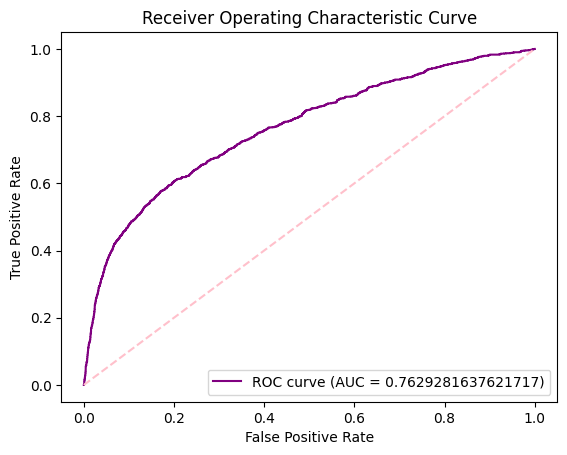

AUC obtained on validation set: 0.7629281637621717


In [15]:
# Code here
import sklearn.metrics as metrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train, X_val, y_train, y_val = train_test_split(sedf_trainx, trainy, test_size=0.3, random_state=810)
clmodel.fit(X_train, y_train)


# Predict probabilities on the validation set
y_probs = clmodel.predict_proba(X_val)
predsy = y_probs[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, predsy)
roc_auc = metrics.auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.title('Receiver Operating Characteristic Curve')
plt.plot(fpr, tpr, 'purple', label=f'ROC curve (AUC = {roc_auc})')
plt.plot([0, 1], [0, 1], color='pink', linestyle='--')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

print("AUC obtained on validation set:", roc_auc)

Q8. What is the AUC obtained?<br>
Ans - 0.7629281637621717

Now Remove the Feature 'Age' from training dataset, train on the data and plot ROC curve.

Q9. What is the AUC Score now?
Ans - 0.7637533957459822

In [16]:
sedf_trainx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 84 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LIMIT_BAL    21000 non-null  float64
 1   AGE          21000 non-null  float64
 2   BILL_AMT1    21000 non-null  float64
 3   BILL_AMT2    21000 non-null  float64
 4   BILL_AMT3    21000 non-null  float64
 5   BILL_AMT4    21000 non-null  float64
 6   BILL_AMT5    21000 non-null  float64
 7   BILL_AMT6    21000 non-null  float64
 8   PAY_AMT1     21000 non-null  float64
 9   PAY_AMT2     21000 non-null  float64
 10  PAY_AMT3     21000 non-null  float64
 11  PAY_AMT4     21000 non-null  float64
 12  PAY_AMT5     21000 non-null  float64
 13  PAY_AMT6     21000 non-null  float64
 14  Pay_0_-1     21000 non-null  float64
 15  Pay_0_0      21000 non-null  float64
 16  Pay_0_1      21000 non-null  float64
 17  Pay_0_2      21000 non-null  float64
 18  Pay_0_3      21000 non-null  float64
 19  Pay_

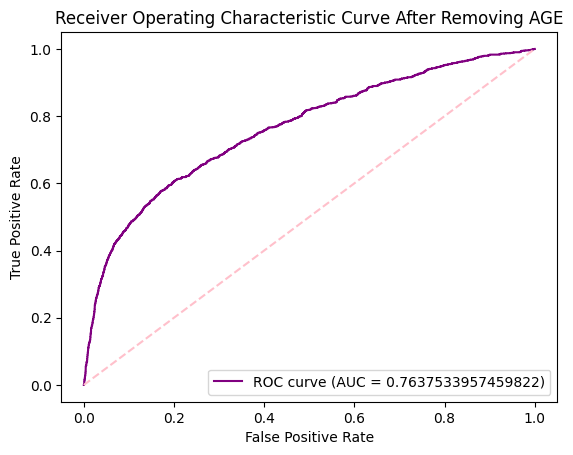

AUC obtained on validation set: 0.7637533957459822


In [17]:
# Code here

x_no_age = sedf_trainx.drop(columns=['AGE'])
X_train2, X_val2, y_train2, y_val2 = train_test_split(x_no_age, trainy, test_size=0.3, random_state=810)

y_train2 = y_train2.values.ravel()
y_val2 = y_val2.values.ravel()


clmodel.fit(X_train2, y_train2)

y_probs2 = clmodel.predict_proba(X_val2)
predsy2 = y_probs2[:, 1]
fpr2, tpr2, thresholds2 = roc_curve(y_val2, predsy2)
roc_auc2 = metrics.auc(fpr2, tpr2)


# Plot ROC curve
plt.figure()
plt.title('Receiver Operating Characteristic Curve After Removing AGE')
plt.plot(fpr, tpr, 'purple', label=f'ROC curve (AUC = {roc_auc2})')
plt.plot([0, 1], [0, 1], color='pink', linestyle='--')
plt.legend(loc='lower right')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

print("AUC obtained on validation set:", roc_auc2)

## Hyperparameters

"Model tuning" refers to model adjustments to better fit the data. This is separate from "fitting" or "training" the model. The fitting/training procedure is governed by the amount and quality of your training data, as the fitting algorithm is unique to each classifier (e.g. logistic regression or random forest).


Build a model with hyperparameter 'C' set to your BEST threshold and penalty set to 'l1'. <br>
Make predictions on cross validation set and compute accuracy, precision, recall and F1 score.
<br>Here, split the training data in the ratio 7:3 for training and validation, and do one time validation against validation dataset.

In [18]:
### WRITE CODE HERE
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(x_no_age, trainy, test_size=0.3, random_state=810)
best_C = bestthre
model_l1 = LogisticRegression(C=best_C, penalty='l1', solver='liblinear', max_iter=500)
model_l1.fit(X_train, y_train)

# Predict probabilities on the validation set
y_probs = model_l1.predict_proba(X_val)[:, 1]
y_preds = (y_probs >= bestthre).astype(int)

# Print the results for L1 Loss
print("Q10. Accuracy:", my_accuracy(y_val, y_preds))
print("Q11. Precision:", my_precision(y_val, y_preds))
print("Q12. Recall:", my_recall(y_val, y_preds))
print("Q13. F1 Score:", my_F1_score(y_val, y_preds))


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Q10. Accuracy: 0.7723809523809524
Q11. Precision: 0.49333333333333335
Q12. Recall: 0.5498938428874734
Q13. F1 Score: 0.5200803212851406


For L1 Loss<br>
Q10 Accuracy<br>
Ans - 0.7723809523809524<br>
Q11 Precision<br>
Ans - 0.49333333333333335<br>
Q12 Recall<br>
Ans - 0.5498938428874734<br>
Q13 F1 Score<br>
Ans - 0.5200803212851406

Build a model with hyperparameter 'C' set to your BEST threshold and penalty set to 'l2'. <br>
Make predictions on cross validation set and compute accuracy, precision, recall and F1 score.
<br>Here, split the training data in the ratio 7:3 for training and validation, and do one time validation against validation dataset.

In [19]:
# Code Here
model_l2 = LogisticRegression(C=best_C, penalty='l2', solver='liblinear', max_iter=500)
model_l2.fit(X_train, y_train)


y_probs2 = model_l2.predict_proba(X_val)[:, 1]
y_preds2 = (y_probs2 >= bestthre).astype(int)


# Print the results for L1 Loss
print("For L2 Loss:")
print("Q14. Accuracy:", my_accuracy(y_val, y_preds2))
print("Q15. Precision:", my_precision(y_val, y_preds2))
print("Q16. Recall:", my_recall(y_val, y_preds2))
print("Q17. F1 Score:", my_F1_score(y_val, y_preds2))

For L2 Loss:
Q14. Accuracy: 0.7749206349206349
Q15. Precision: 0.4984066284257489
Q16. Recall: 0.5534324133050248
Q17. F1 Score: 0.5244802146210596


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


For L2 Loss<br>
Q14 Accuracy<br>
Ans - 0.7749206349206349<br>
Q15 Precision<br>
Ans - 0.4984066284257489<br>
Q16 Recall<br>
Ans - 0.5534324133050248<br>
Q17 F1 Score<br>
Ans - 0.5244802146210596

Q18. Which of the above models is better? <br>
Ans - L2 is better, with higher accuracy, recall and F1 score, which indicates it can identify positive cases while maintaining a balance between precision and recall. And this is very important under this scenario.








# Test set

You have worked on training and cv dataset so far, but testing data does not include the labels. Choose the best hyperparameter values as seen in previous section and build a model. Use this model to make predictions on test set.

In [20]:
testy = pd.read_csv('CreditDefault_test_y.csv')
best_penalty = 'l2'

final_model = LogisticRegression(C=best_C, penalty=best_penalty, solver='liblinear', max_iter=500)
final_model.fit(sedf_trainx, trainy)


y_probs_test = final_model.predict_proba(sedf_testx)[:, 1]
y_predsf = (y_probs_test >= bestthre).astype(int)


print("Q19. Test Metrics:")
print("Test Accuracy:", my_accuracy(testy, y_predsf))
print("Test Precision:", my_precision(testy, y_predsf))
print("Test Recall:", my_recall(testy, y_predsf))
print("Test F1 Score:", my_F1_score(testy, y_predsf))


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Q19. Test Metrics:
Test Accuracy: 0.7832222222222223
Test Precision: 0.5100965759438104
Test Recall: 0.5818728092138208
Test F1 Score: 0.543625730994152


In [21]:
print(y_predsf)

[1 1 1 ... 0 0 0]


Q19. Give Test Accuracy, Precision, Recall and F1 Score. Is it better or worse than the training metrics?

Test Accuracy: 0.7832222222222223

Test Precision: 0.5100965759438104

Test Recall: 0.5818728092138208

Test F1 Score: 0.543625730994152

Testing on the test dataset shows higher accuracy, precision,recall, and F1 score compared to the validation set from the training data. Thus, it is better than the training metrics.

# Decision Trees
The dataset you will be using in the following parts is the "Pima Indians Diabetes Dataset".

There are two data files: "Diabetes_training.csv" and "Diabetes_Xtest.csv"
Both files have the following fields, except quality which is not available in "Diabetes_Xtest.csv".

Features:

1 - pregnant:	Number of times pregnant <br>
2 - glucose:	Plasma glucose concentration (glucose tolerance test) <br>
3 - pressure:	Diastolic blood pressure (mm Hg) <br>
4 - triceps:	Triceps skin fold thickness (mm) <br>
5 - insulin	2-Hour serum insulin (mu U/ml) <br>
6 - mass:	Body mass index (weight in kg/(height in m)\^2) <br>
7 - pedigree:	Diabetes pedigree function <br>
8 - age:	Age (years)<br>

Target:

diabetes: ('neg','pos')

Training dataset, "Diabetes_training.csv", contains 576 rows and 9 columns. This is the training set containing both of the features and the target.
Test dataset, "Diabetes_Xtest.csv", contains 192 rows and 8 columns. This is the test set which only contains the features.
Prediction task is to determine the test for diabetes. (If you transfrom the target as binary values, please make sure "pos" is 1, "neg" is 0)



First upload the training set

In [ ]:
import numpy as np
import pandas as pd
import io

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Diabetes_training.csv to Diabetes_training.csv
Saving Diabetes_Xtest.csv to Diabetes_Xtest.csv


In [ ]:
data_train = pd.read_csv('Diabetes_training.csv')
data_test = pd.read_csv('Diabetes_Xtest.csv')
data_train.head()

,pregnant,glucose,pressure,triceps,insulin,mass,pedigree,age,diabetes
0,13,129,0,30,0,39.9,0.569,44,pos
1,9,184,85,15,0,30.0,1.213,49,pos
2,3,193,70,31,0,34.9,0.241,25,pos
3,4,146,78,0,0,38.5,0.520,67,pos
4,3,174,58,22,194,32.9,0.593,36,pos


In [ ]:
# Split data into X and y
X = data_train.iloc[:, :-1]
y = data_train.iloc[:, -1]
y = pd.get_dummies(y, drop_first=True)
y.head()

,pos
0,True
1,True
2,True
3,True
4,True


Plot a histogram of X to understand the distributions of the continuous values.

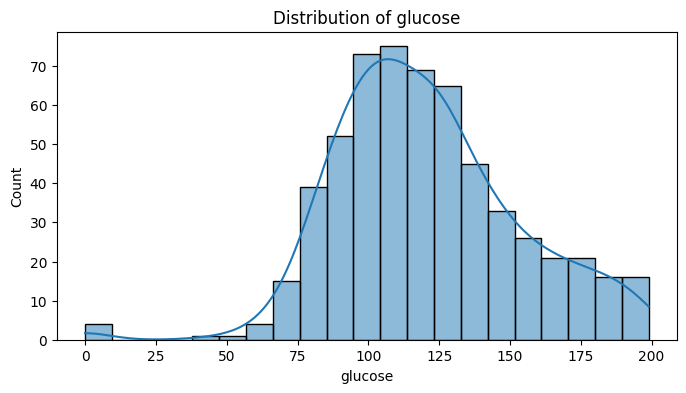

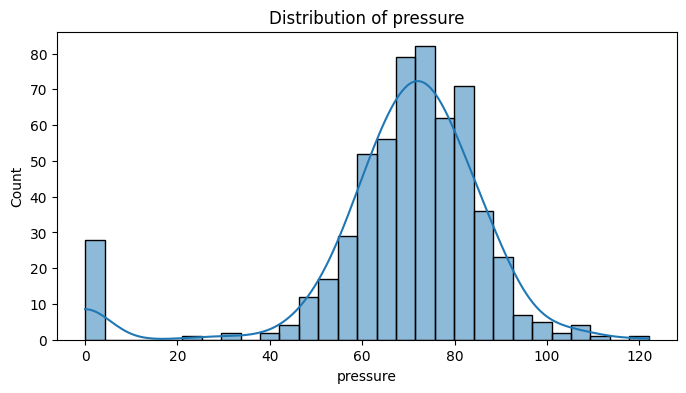

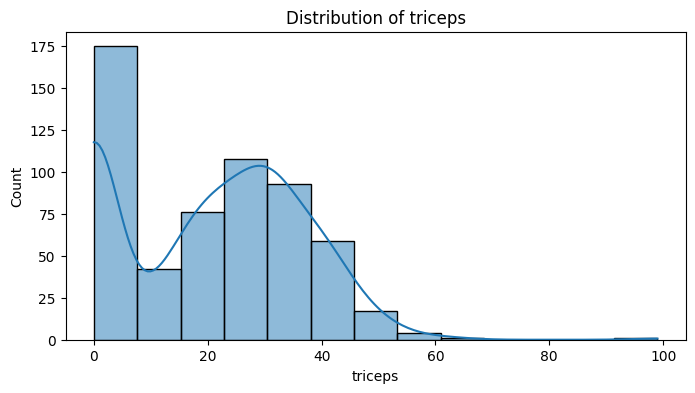

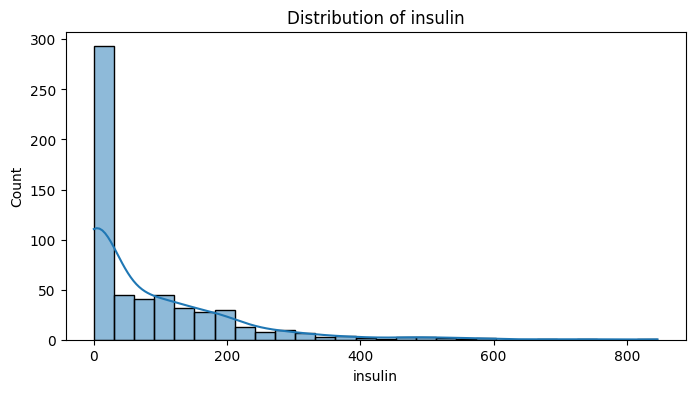

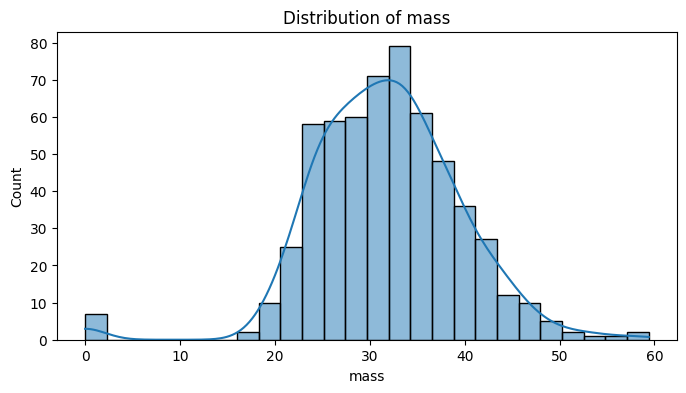

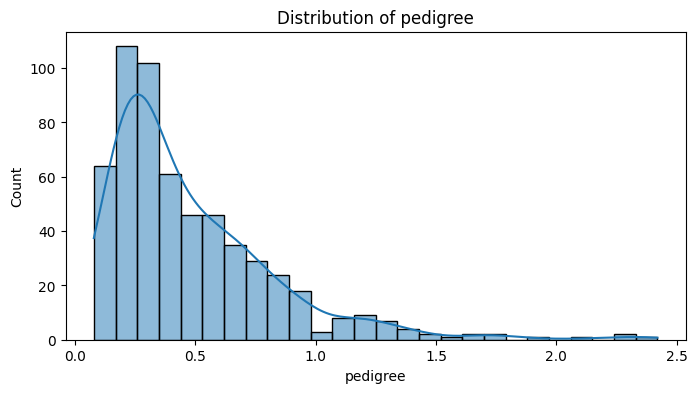

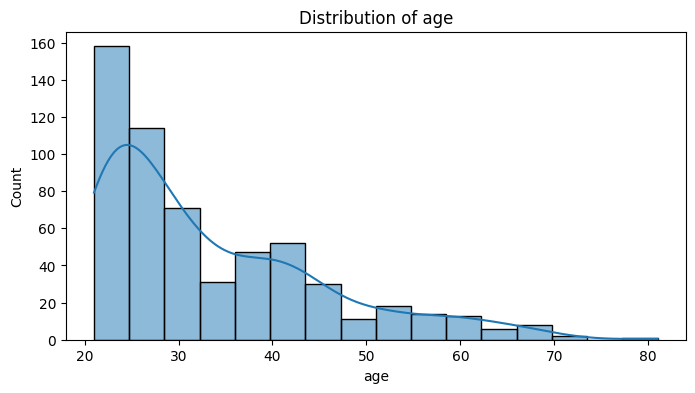

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Plot histograms for each feature in X
continuous_data = ['glucose','pressure', 'triceps','insulin','mass','pedigree','age']

for i in continuous_data:
    plt.figure(figsize=(8, 4))
    sns.histplot(X[i], kde=True)
    plt.title(f'Distribution of {i}')
    plt.show()


#### **Skewness of data**:

In probability theory and statistics, skewness is a measure of the asymmetry of the probability distribution of a real-valued random variable about its mean.

If tail is on the right as that of the first image in the figure, it is right skewed data. It is also called positive skewed data.
Common transformations of this data include square root, cube root, and log.

If the tail is to the left of data, then it is called left skewed data. It is also called negatively skewed data.
Common transformations include square , cube and exponentiation.

According to the above histogram, perform transformations on the skewed features so that the distribution of these features becomes closer to a normal distribution.

Q20. According to the above histogram, can you see any skewed features? Which features are skewed? Are they left-skewed or right-skewed?

Ans - According to the histogram above, the glucose feature is approximately normally distributed but is somewhat right-skewed. The pressure feature is also close to a normal distribution, with a slight right skew. The triceps feature has a right-skewed distribution. The insulin feature is highly right-skewed. The mass feature appears to be skewed to the right but is closer to a normal distribution compared to other features. The pedigree feature has a right-skewed distribution, and the age feature is also right-skewed.

In summary, all of the features are right-skewed, but the glucose, pressure, and mass features are less skewed and close to normal distribution.




Standardize the features

In [ ]:
# Replace zero value with population mean
X_train_norm = X.copy()
X_test_norm = data_test.copy()

replace_column = ['glucose', 'pressure', 'triceps', 'insulin', 'mass']

for column in replace_column:
    non_zero_mean = X_train_norm[X_train_norm[column] != 0][column].mean()
    X_train_norm[column] = X_train_norm[column].replace(0, non_zero_mean)
    X_test_norm[column] = X_test_norm[column].replace(0, non_zero_mean)

In [ ]:
# Apply logarithm or box-cox transformation for skewed data
# Apply same transformation to the test set simultaneously
from scipy.stats import boxcox
right_skewed_1 = ['insulin', 'pedigree'] # Right skewed Data with non-zero value
right_skewed_2 = ['age'] # Right skewed Data cannot be normalized by log transformation, we use more aggresive box-cox transformation
right_skewed_3 = ['pregnant'] # Right skewed Data with zero value

for column in right_skewed_1:
    X_train_norm[column] = np.log(X_train_norm[column])
    X_test_norm[column] = np.log(X_test_norm[column])

for column in right_skewed_2:
    transformed_data, lambda_value = boxcox(X[column])
    X_train_norm[column] = transformed_data
    X_test_norm[column] = (X_test_norm[column] ** lambda_value - 1) / lambda_value

for column in right_skewed_3:
    X_train_norm[column] = np.log(X_train_norm[column] + 1)
    X_test_norm[column] = np.log(X_train_norm[column] + 1)

In [ ]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

fit = scaler.fit(X_train_norm)
X_train_norm = fit.transform(X_train_norm)
X_test_norm = fit.transform(X_test_norm)#

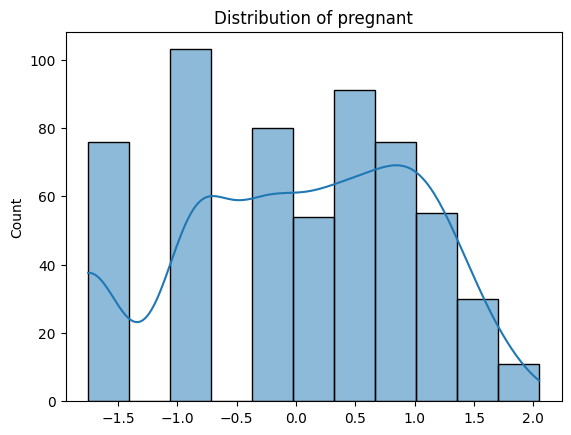

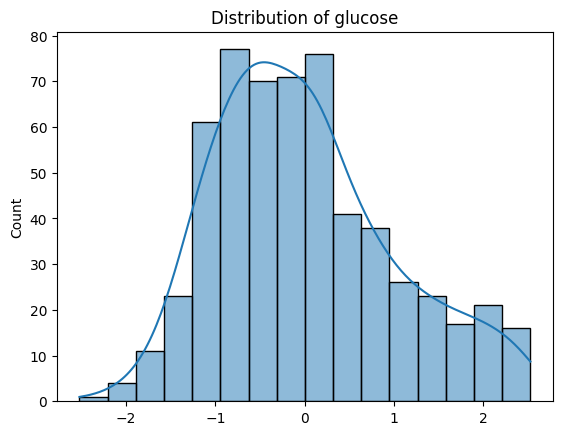

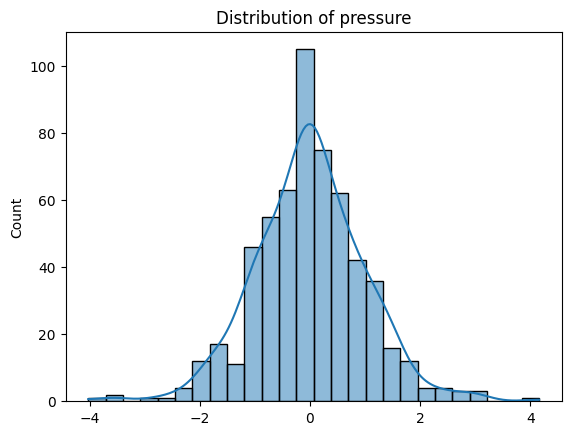

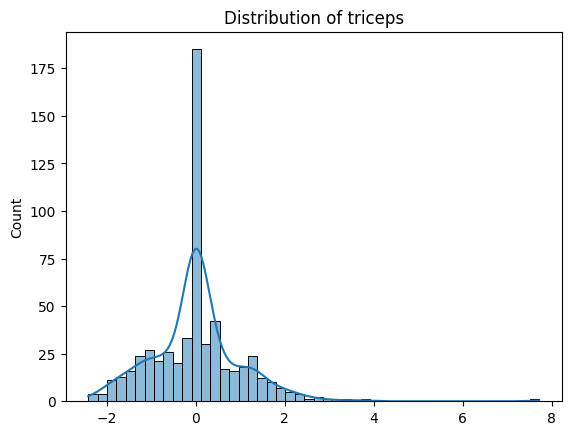

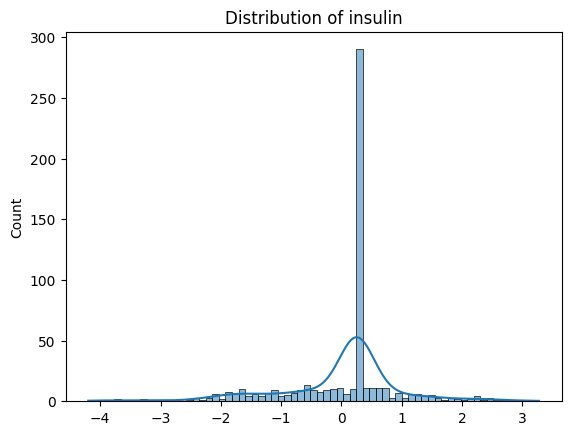

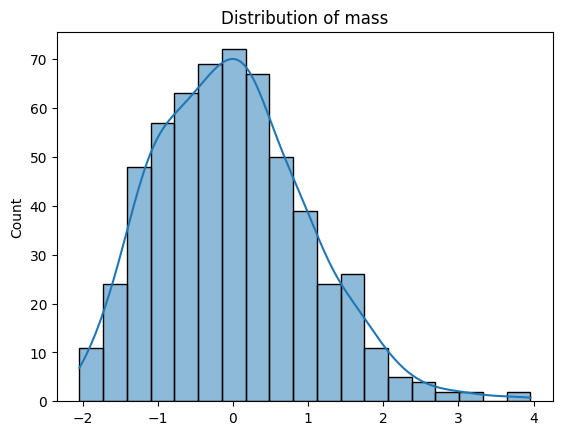

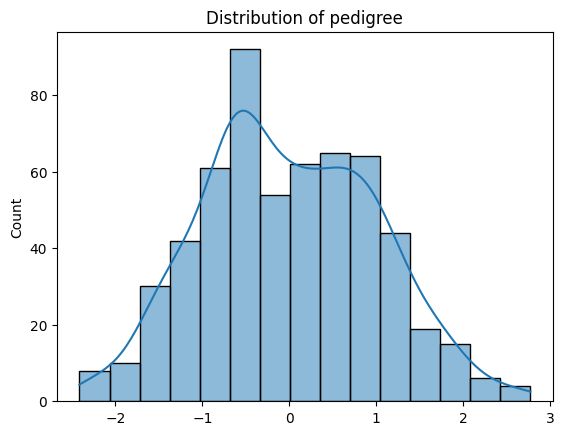

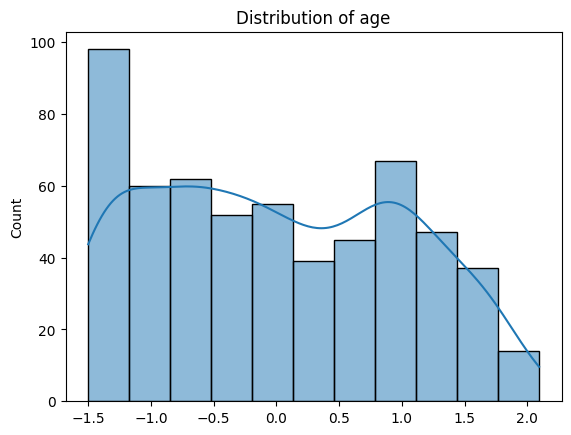

In [ ]:
# Show the histogram of the transformed data
for i in range(8):
    sns.histplot(X_train_norm[:,i], kde=True)
    plt.title(f'Distribution of {X.columns[i]}')
    plt.show()

Splitting training data into training and validation set (the code has been provided)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dividing the data into training and validation set
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train_norm, y, test_size = 0.3, random_state=20)

X_train.shape

(403, 8)

In [ ]:
y_train.to_csv('Diabetes_training_y.csv', index=False)

### Decision Tree
From sklearn.tree use DecisionTreeClassifier to build a classification model with default parameters.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
### Fit the classifier on the training data
# Please set random_state=30
### WRITE CODE HERE ###

classifier = DecisionTreeClassifier(random_state=30)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=30)

In [ ]:
### Make predictions on the training data

### WRITE CODE HERE ###
y_train_pred = classifier.predict(X_train)
print(y_train_pred)

[False False  True False  True False False False False  True  True False
 False False  True  True False  True False False False False False False
  True False False False  True False False  True False False False False
 False False False  True  True  True  True False  True  True False  True
 False False  True False False  True  True  True False False False False
 False False False False False  True  True  True False  True  True False
 False False False  True False False False False  True False  True  True
  True  True False False False False  True False False False False  True
 False  True False False  True  True False False False False False  True
 False  True False False False False False False False  True False False
 False False False  True  True False False False False False False False
 False False  True  True False  True False False False  True False  True
 False False False  True  True  True False False False False False  True
 False False False False False  True False False  T

Q21. Print accuracy, prediction and recall for the predictions made on the training data.

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
### WRITE CODE HERE ###
accuracy = accuracy_score (y_train,y_train_pred)
precision = precision_score (y_train,y_train_pred)
recall = recall_score (y_train,y_train_pred)

print(f"Accuracy on training data: {accuracy:.3f}")
print(f"Precision on training data: {precision:.3f}")
print(f"Recall on training data: {recall:.3f}")

Accuracy on training data: 1.000
Precision on training data: 1.000
Recall on training data: 1.000


Q22 Print out the confusion matrix for training predictions.

In [ ]:
from sklearn.metrics import confusion_matrix
# Code Here
confusion_matrix = confusion_matrix (y_train,y_train_pred)
print("Confusion Matrix for training data:")
print(confusion_matrix)

Confusion Matrix for training data:
[[254   0]
 [  0 149]]


In [ ]:
### Make predictions on the validation data
### WRITE CODE HERE ###

y_val_pred = classifier.predict(X_val)
print(y_val_pred)

[False False False False  True False False False False False False False
 False  True  True False False False  True False False False  True False
  True False False False False False  True False False False  True  True
 False  True False  True False  True False False False  True  True False
  True False False False  True  True False  True False  True False False
  True False  True False  True  True  True False  True  True  True False
 False  True False  True False False  True  True  True False False  True
 False  True False False  True False False  True  True False  True False
  True  True False False  True  True False False False False False  True
 False  True False  True False  True False False False False  True False
 False False False False False False  True False  True False False False
 False False False  True  True False False False False False False False
  True  True  True False  True False  True False  True  True  True  True
 False  True  True  True False False  True  True Fa

Q23.1. Print Confusion Matrix for Validation Dataset Predictions.

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix_val = confusion_matrix (y_val,y_val_pred)
print("Confusion Matrix for validation data:")
print(confusion_matrix_val)

Confusion Matrix for validation data:
[[86 35]
 [19 33]]


Q23.2. Print accuracy, prediction and recall for the predictions made on the validation data.

In [ ]:
### WRITE CODE HERE ###
from sklearn.metrics import accuracy_score,precision_score,recall_score
accuracy_val = accuracy_score (y_val,y_val_pred)
precision_val = precision_score (y_val,y_val_pred)
recall_val = recall_score (y_val,y_val_pred)

print(f"Accuracy on validation data: {accuracy_val:.3f}")
print(f"Precision on validation data: {precision_val:.3f}")
print(f"Recall on validation data: {recall_val:.3f}")

Accuracy on validation data: 0.688
Precision on validation data: 0.485
Recall on validation data: 0.635


Q24. Plot ROC curve and obtain AUC for predictions on the validation data.

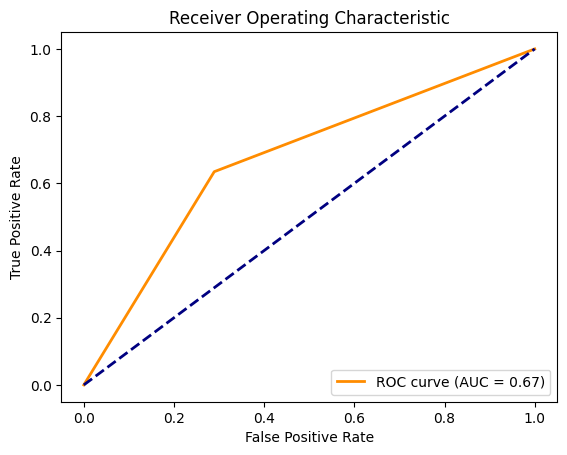

In [ ]:
# Plot the ROC curve by giving appropriate names for title and axes.

### WRITE CODE HERE
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt

# Compute ROC curve and ROC area
y_scores = classifier.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_scores)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Q25. Based on the scores for training set and validtion set, explain the performance of the above model in terms of bias and variance.<br>

Ans - Based on the ROC curve on validation data sets, we have AUC = 0.85, suggesting that the model is performing well but not perfect. Specifically, the accuracy drops to 0.728, with lower precision 0.538, indicating that a large portion of positive predication are not correct, and recall of 0.673, showing that the model misses many true posisitve.

 Note that the model performs perfectly on the training data, with both precision and recall of 1, but followed by a significant drop in validation data sets. This shows that the model might have high variance and might be overfitting the training data.

### Random Forest


Decision Trees have low predictive power compared to other methods due to high variance. Random Forest increases prediction power at the expense of decreased interpretability.


From sklearn.ensemble use RandomForestClassifier to build a classification model with default parameters.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
### Fit the classifier on the training data
# Please set random_state=30
### WRITE CODE HERE ###
classifier_RF = RandomForestClassifier(random_state=30)
classifier_RF.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=30)

In [ ]:
### Make predictions on the training data
### WRITE CODE HERE ###
y_train_pred_RF = classifier_RF.predict(X_train)
print(y_train_pred_RF)

[False False  True False  True False False False False  True  True False
 False False  True  True False  True False False False False False False
  True False False False  True False False  True False False False False
 False False False  True  True  True  True False  True  True False  True
 False False  True False False  True  True  True False False False False
 False False False False False  True  True  True False  True  True False
 False False False  True False False False False  True False  True  True
  True  True False False False False  True False False False False  True
 False  True False False  True  True False False False False False  True
 False  True False False False False False False False  True False False
 False False False  True  True False False False False False False False
 False False  True  True False  True False False False  True False  True
 False False False  True  True  True False False False False False  True
 False False False False False  True False False  T

Q26. Print default settings for the Random Forest. max_depth, max_features, min_samples_leaf, min_samples_split, n_estimators for the random forest classfier. What do each of these mean?

In [ ]:
# Q26 Code Here
from sklearn.ensemble import RandomForestClassifier

print("max_depth:", classifier_RF.max_depth)
print("max_features:", classifier_RF.max_features)
print("min_samples_leaf:", classifier_RF.min_samples_leaf)
print("min_samples_split:", classifier_RF.min_samples_split)
print("n_estimators:", classifier_RF.n_estimators)



max_depth: None
max_features: sqrt
min_samples_leaf: 1
min_samples_split: 2
n_estimators: 100


What do each of these mean?
The max depth
The max features sqrt,
The min samples leaf,
The min samples split,
The n_estimators,

Q27 Find the min_depth, max_depth and Avg Tree Length of the Trees in the Random Forest

In [ ]:
# Q27 Code Here
tree_depths = [estimator.tree_.max_depth for estimator in classifier_RF.estimators_]

min_depth = min(tree_depths)
max_depth = max(tree_depths)
avg_depth = np.mean(tree_depths)

print("Min Depth:", min_depth)
print("Max Depth:", max_depth)
print("Average Depth:", avg_depth)

Min Depth: 10
Max Depth: 18
Average Depth: 13.73


Q28. Print accuracy, prediction and recall for the predictions made on the training data.

In [ ]:
from sklearn.metrics import accuracy_score,precision_score, recall_score
### WRITE CODE HERE ###

print("Training accuracy:", accuracy_score(np.ravel(y_train), y_train_pred_RF))
print("Training precision:", precision_score(np.ravel(y_train), y_train_pred_RF))
print("Training recall:", recall_score(np.ravel(y_train), y_train_pred_RF))

Training accuracy: 1.0
Training precision: 1.0
Training recall: 1.0


Q29 Confusion Matrix for Training Data Predictions

In [ ]:
# Code here
from sklearn.metrics import confusion_matrix
confusion_matrix_val_rf = confusion_matrix (y_train,y_train_pred_RF)
print("Confusion Matrix for validation data:")
print(confusion_matrix_val_rf)

Confusion Matrix for validation data:
[[254   0]
 [  0 149]]


In [ ]:
### Make predictions on the testing data

### WRITE CODE HERE ###
y_pred_val_RF = classifier_RF.predict(X_val)

Q30. Print accuracy, prediction and recall for the predictions made on the validation data.

In [ ]:
print("Validation accuracy:", accuracy_score(y_val, y_pred_val_RF))
print("Validation precision:", precision_score(y_val, y_pred_val_RF))
print("Validation recall:", recall_score(y_val, y_pred_val_RF))

Validation accuracy: 0.7745664739884393
Validation precision: 0.6031746031746031
Validation recall: 0.7307692307692307


Q31. What's the best Metric to be used to evaludate the model? Recall, Precision or Accuracy?

In [ ]:
### WRITE CODE HERE ###
print('The best metric to be used to evaluate the model is Recall.')

The best metric to be used to evaluate the model is Recall.


Q32. Plot ROC curve and obtain AUC for the validation predictions

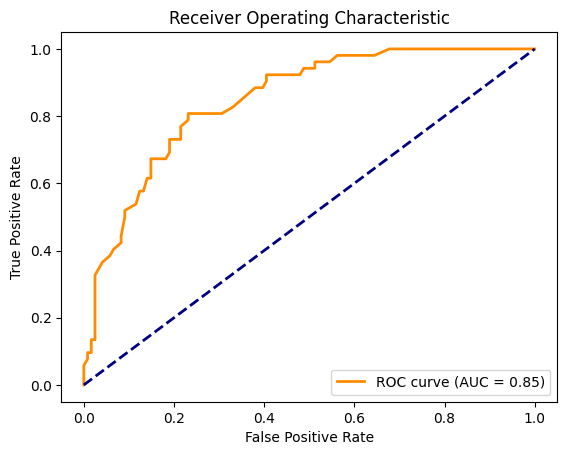

In [ ]:
# Plot the ROC curve by giving appropriate names for title and axes.

# Compute ROC curve and ROC area
y_scores_RF = classifier_RF.predict_proba(X_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, y_scores_RF)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Q33. Based on the scores for training set and test set, explain the performance of the above model in terms of bias and variance. Is the Random Forest model better or worse than the Decision Tree model? Explain why you think the performance may have improved or deteriorated.

Ans - Based on provided information, the random forest model is better than the decision tree model. Random forest model seems will be less overfitted which random Forest (accuracy ~77%, precision ~60%, recall ~73%) indicate an improvement over a typical single Decision Tree. Besides, the AUC is 0.85 which means good performance in distinguishing between classes. So the random forest model may be the better to use.


## Hyperparameters

"Model tuning" refers to model adjustments to better fit the data. This is separate from "fitting" or "training" the model. The fitting/training procedure is governed by the amount and quality of your training data, as the fitting algorithm is unique to each classifier (e.g. logistic regression or random forest).

However, there are aspects of some models that are user specified. For example, when using a random forest (which is basically an ensemble of decision trees), it is probably a good idea to choose the right number of underlying trees. Too many and the model might overfit, and too few and the model might not be able to properly learn the data. Parameters such as these are referred to as "hyperparameters" or "free parameters", as the values for these are determined by the user and not the algorithm.

A quick and efficient way to optimize hyperparameters is to perform Grid Search over different values of the parameters.

In [ ]:
from pprint import pprint
# Look at parameters used by our current forest
# Please set random_state=30 for all instances of random forest
print('Parameters currently in use:\n')
pprint(classifier_RF.get_params())

Parameters currently in use:

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 30,
 'verbose': 0,
 'warm_start': False}


In [ ]:
# In the below dictionary, fill in the list of values that you want to try out for each parameter
# Refer to the descriptions in sklearn.ensemble.RandomForestClassifier's doc to understand what the parameters depict

param_grid = {
    'max_depth': [3,5,7,9,11], # Choose upto 5 appropriate values
    'max_features': [2,3,4], # Choose upto 5 appropriate values
    'min_samples_leaf': [2,3,4], # Choose upto 3 appropriate values
    'min_samples_split': [4,6,8,10], # Choose upto 4 appropriate values
    'n_estimators': [10,20,30,40,50] # Choose upto 5 appropriate values
}

USE YOUR WHOLE TRAINING DATA FOR k-FOLD CROSS VALIDATION IN GRIDSEARCHCV FOR RANDOM FOREST. <br>
Think of what metric you would use for scoring the classifier?

In [ ]:
from sklearn.model_selection import GridSearchCV
rtc = RandomForestClassifier(random_state=30)
grid_search = GridSearchCV(
    estimator=rtc,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='f1'
)

In [ ]:
### Fit the training data
### WRITE CODE HERE ###
grid_search.fit(X_train_norm, np.ravel(y))

Fitting 5 folds for each of 900 candidates, totalling 4500 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=30), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 9, 11],
                         'max_features': [2, 3, 4],
                         'min_samples_leaf': [2, 3, 4],
                         'min_samples_split': [4, 6, 8, 10],
                         'n_estimators': [10, 20, 30, 40, 50]},
             scoring='f1', verbose=1)

Q34. Display the parameters of the best model.

In [ ]:
# Print the best parameters
### WRITE CODE HERE ###
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 11, 'max_features': 3, 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 40}


Q35. Print the best Score. What metric did you use for scoring?

In [ ]:
# Print the best score
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Cross-Validation Score: 0.6845644345644345


Q36. accuracy, precision and recall for training dataset

In [ ]:
y_pred = grid_search.predict(X_train)
print("Training accuracy :",accuracy_score(y_train, y_pred))
print("Training precision :",precision_score(y_train, y_pred))
print("Training recall :",recall_score(y_train, y_pred))

Training accuracy : 0.9454094292803971
Training precision : 0.950354609929078
Training recall : 0.8993288590604027


Q37. accuracy, precision and recall for validation dataset

In [ ]:
### Using the best model, do the following:
### Make predictions on the training set and display accuracy, precision and recall.
### Make predictions on the validation set and display accuracy, precision and recall.

### Using the best model, do the following:
### Make predictions on the training set and display accuracy, precision and recall.
### WRITE CODE HERE ###

### Make predictions on the validation set and display accuracy, precision and recall.

### WRITE CODE HERE ###
y_pred_val = grid_search.predict(X_val)
print("validation accuracy :",accuracy_score(y_val, y_pred_val))
print("validation precision :",precision_score(y_val, y_pred_val))
print("validation recall :",recall_score(y_val, y_pred_val))

validation accuracy : 0.9421965317919075
validation precision : 0.92
validation recall : 0.8846153846153846


Q38. Plot ROC and Get AUC for the Classifier

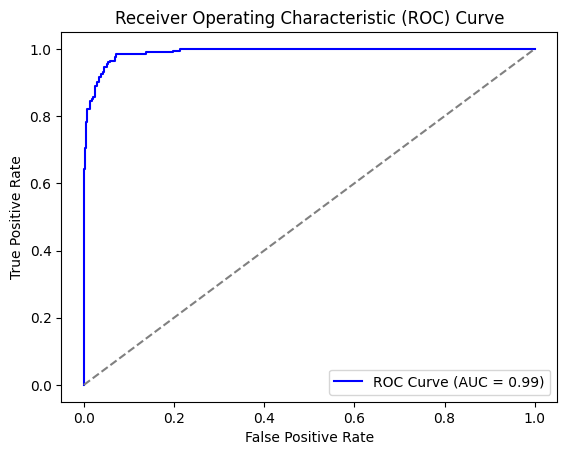

In [ ]:
# Plot the ROC curve by giving appropriate names for title and axes.

## WRITE CODE HERE
y_scores = grid_search.predict_proba(X_train_norm)[:, 1]
fpr, tpr, _ = roc_curve(y, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

#### Test
Choose the best hyperparameter values from the previous section. Use this random forest model to make predictions on test set.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CreditDefault_test_X.csv to CreditDefault_test_X (11).csv
Saving CreditDefault_test_y.csv to CreditDefault_test_y (11).csv
Saving CreditDefault_train_X.csv to CreditDefault_train_X (11).csv
Saving CreditDefault_train_y.csv to CreditDefault_train_y (11).csv
Saving Diabetes_training.csv to Diabetes_training (11).csv
Saving Diabetes_Xtest.csv to Diabetes_Xtest (11).csv


In [ ]:
#same data processing as the training set
#Processing has been done simultaneously in Standardization Part
X_test_norm

array([[-0.05269192, -1.05685619, -0.51697511, ..., -0.60034344,
        -1.26420215, -1.50101004],
       [-0.18025339, -0.1774334 ,  0.15099391, ..., -0.9643469 ,
        -0.98419458,  0.00443548],
       [-0.60751815, -1.41513955, -1.85291313, ..., -0.17809941,
        -0.66669461, -0.53007806],
       ...,
       [-0.60751815, -0.43800311, -0.85095961, ..., -0.90610635,
        -0.82725034, -0.69179592],
       [-0.2228826 ,  0.21342117,  1.31993968, ...,  0.62270822,
         1.52391427,  0.65098781],
       [-0.77642534,  0.01799389, -0.1829906 , ...,  0.66638863,
        -0.18994434, -0.38088364]])

In [ ]:
# Construct your final random forest using the best hyperparameters obtained above
rfc_final = RandomForestClassifier(max_depth=11, max_features=3, min_samples_leaf=3, min_samples_split=4, n_estimators=40)
rfc_final.fit(X_train_norm, np.ravel(y))
# return the prediction for test dataset as "y_pred2"
y_pred2 = rfc_final.predict(X_test_norm)

In [ ]:
# Print y_pred2
print(y_pred2)

[False False False  True  True  True False  True False False False False
  True False False False False  True False False  True  True False  True
 False  True False  True False  True  True False False  True False  True
 False False False False False False  True False False False  True False
 False  True False False False False  True False False False False  True
 False  True False False False  True False False False False False False
 False False False  True False  True  True  True False False False False
 False  True  True False False False False False  True False  True  True
  True False False  True  True False False  True False False  True False
 False False  True False False False False False  True  True False False
  True False False False False  True False False False False False False
 False False False  True  True False False False False  True False False
 False False False  True  True  True False False  True  True False False
 False  True False  True False False False False Fa